In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

In [10]:
def sist_ecs(u,x,t,D=0.5):
    # Ojo este ejemplo no usa explicitamente x y t
    dx = x[1]-x[0]
    Nx = len(u)
    dui = np.zeros_like(u)
    for i in range(1,Nx-1):
        dui[i] = D*( u[i+1] - 2*u[i] + u[i-1] )/dx**2
    return dui

def RK4_EDP_F1D(f,x,t,f0,D=0.5):
    sol = np.zeros( (len(x),len(t)) )
    dx , dt = x[1]-x[0] , t[1]-t[0]
    r = D*dt/dx**2
    print('r= ',r)
    if r < 0.5:
        sol[:,0] = f0
        for n in range(len(t)-1):
            k1 = f( sol[:,n] , x , t[n] )
            k2 = f( sol[:,n]+0.5*k1*dt , x , t[n]+0.5*dt )
            k3 = f( sol[:,n]+0.5*k2*dt , x , t[n]+0.5*dt )
            k4 = f( sol[:,n]+k3*dt , x , t[n]+dt )
            sol[:,n+1] =  sol[:,n] + (dt/6)*(k1 + 2*k2 + 2*k3 + k4)
    else:
        print('No hay convergencia')
    return sol

r=  0.4803921568627452


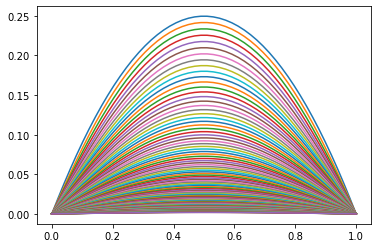

In [15]:
x , t = np.linspace(0,1,50) , np.linspace(0,1,2500)
P0 = -x*(x-1)
u_x_t = RK4_EDP_F1D(sist_ecs,x,t,P0)
for i in range(1,len(t),20):
    plt.plot(x,u_x_t[:,i])    
plt.savefig('Fourier_imag.pdf')

In [6]:
fig , ejes = plt.subplots(1,1)
ejes.set_xlim([x[0],x[-1]]),ejes.set_ylim([0,max(P0)])
ejes.set_aspect('equal')

Psi_i, = ejes.plot([],[],color='red')

def cuadro(n):
    Psi_i.set_data(x,u_x_t[:,n])
    return Psi_i,

animacion = FuncAnimation(fig,cuadro,frames=len(t),
                          interval = 40,blit=True)

plt.close()
animacion.save('Fourier_peli1.mp4',writer='ffmpeg',fps=60)

In [16]:
def P0_barritas(x,T_max=1):
    P0 = np.zeros_like(x)
    for i in range(len(x)):
        if 0.3 < x[i] < 0.6:
            P0[i] = T_max
    return P0

r=  0.4803921568627452


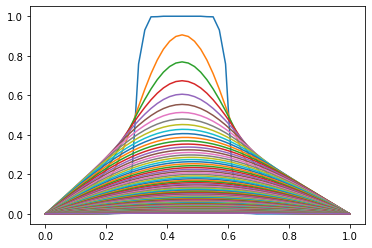

In [18]:
x , t = np.linspace(0,1,50) , np.linspace(0,1,2500)
P0 = P0_barritas(x)
u_x_t = RK4_EDP_F1D(sist_ecs,x,t,P0)
for i in range(1,len(t),20):
    plt.plot(x,u_x_t[:,i])
plt.savefig('Fourier_barritas.pdf')

In [9]:
fig , ejes = plt.subplots(1,1)
ejes.set_xlim([x[0],x[-1]]),ejes.set_ylim([0,max(P0)+0.1])
ejes.set_aspect('equal')

Psi_i, = ejes.plot([],[],color='red')

def cuadro(n):
    Psi_i.set_data(x,u_x_t[:,n])
    return Psi_i,

animacion = FuncAnimation(fig,cuadro,frames=len(t),
                          interval = 40,blit=True)

plt.close()
animacion.save('Fourier_peli2.mp4',writer='ffmpeg',fps=60)